# Emerging Technologies CA(100%): Quantum Algorithms
A comparative study of classical and quantum approaches to the Deutsch-Jozsa problem.

__Module:__ Emerging Technologies

__Academic Year:__ 2025/2026

__Author:__ Tomás Pettit

## Introduction
This notebook investigates the foundational distinctions between classical and quantum computation through the lens of the [Deutsch-Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa), one of the earliest quantum algorithms to demonstrate a provable advantage over classical methods. By exploiting quantum **superposition** and interference, the algorithm determines global properties of a Boolean function with remarkable efficiency, offering a clear illustration of how quantum computation departs from classical paradigms.

## The Problem
We consider a Boolean function that is guaranteed to be either **constant** — returning the same output for all inputs — or **balanced**, returning ``True`` for exactly half of its inputs and ``False`` for the other half. A classical deterministic algorithm must, in the worst case, evaluate the function on more than half of the input domain to distinguish these cases. As the input size grows, this requirement scales exponentially.

In contrast, the [Deutsch-Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa) resolves the problem with a _single_ oracle query, regardless of input size. This dramatic reduction illustrates the potential of quantum computation to outperform classical methods for specific problem classes.

## Notebook Structure
This notebook is organized into five interconnected components:

1. __Problem 1:__ Construction of classical Boolean function generators
2. __Problem 2:__ Implementation and analysis of the classical solution
3. __Problem 3:__ Quantum oracle construction
4. __Problem 4:__ Deutsch's Algorithm with Qiskit
5. __Problem 5:__ Deutsch-Jozsa Scale of 4‑bit function

## Technologies Used
- __Python 3.12+__
- [Qiskit](https://qiskit.org/) for quantum circuit construction and simulation
- [Matplotlib](https://matplotlib.org/) for visualization and analysis
- [NumPy](https://numpy.org/) for numerical computations

All code follows [PEP 8](https://peps.python.org/pep-0008/) style guidelines and includes comprehensive documentation.

## Imports

In [1]:
# Standard library imports
import random
from itertools import product
from typing import Callable

# Visualization imports & Numerical Operation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Quantum computing
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

## Problem 1: Generating Random Boolean Functions
### Problem Context

This problem creates example Boolean functions that will be used in later parts of the assignment. The Deutsch–Jozsa algorithm assumes that a function is either **constant** or **balanced**, and its goal is to determine which type it is without knowing how the function works internally.

*Problem 1* provides these functions in a classical form so they can be tested and analysed in both classical and quantum settings later in the notebook.

----------

### Explanation

A Boolean function is a function that maps Boolean inputs to a Boolean output. In this problem, each function takes  **four Boolean inputs**, meaning there are  possible input combinations. The function returns a single Boolean value (`True` or `False`) for each of these combinations.

The purpose of this problem is to **randomly** generate functions that are  _guaranteed_  to be either constant or balanced. This mirrors the oracle model used in quantum computing, where the internal behaviour of the function is hidden and only its outputs can be observed through evaluation.

----------

### Definitions

**Constant function**  
A Boolean function is constant if it returns the same output for every possible input. For four input bits, this means the function returns either:
-  `False` for all 16 input combinations, OR
-  `True` for all 16 input combinations.

**Balanced function**  
A Boolean function is balanced if it returns `True` for exactly half of all possible inputs and `False` for the other half. With four input bits, this corresponds to:

-   8 inputs returning `True`
-   8 inputs returning `False`

### Example
The table below shows the difference between **constant** and **balanced** Boolean functions using a small sample of input combinations. Each input consists of four Boolean values, and the output is a single Boolean value.

| ``True``	| ``False``	| Result |
|--|--|--|
| 0	| 16	| Constant |
| 8	|	8	|	Balanced |
| 16	|	8	|	Constant |

In the constant case, the output is the same for every input. In the balanced case, the outputs are split evenly between ``True`` and ``False`` across all possible inputs (only a subset is shown here).

### Implementation Goal
The function ``random_constant_balanced()`` should:
- Randomly choose whether to generate a **constant** or **balanced** function
- Construct a valid function of four Boolean inputs
- Guarantee that the returned function satisfies the Deutsch–Jozsa promise
- Use Python’s [``random`` module](https://www.w3schools.com/python/ref_random_random.asp) for selection
- Use [itertools.product](https://docs.python.org/3/library/itertools.html#itertools.product) to enumerate all input combinations when needed

This ensures that each invocation produces a fresh, valid test function for subsequent analysis.

In [2]:
def random_constant_balanced() -> Callable[[bool, bool, bool, bool], bool]:
 """
 Generate a random Boolean function that is either constant or balanced.
    
 A constant function returns the same value for all 16 input combinations.
 A balanced function returns True for exactly 8 inputs and False for 8.
    
 Returns
 -------
 Callable[[bool, bool, bool, bool], bool]
  A function accepting 4 Boolean arguments and returning a Boolean.
        
 Example
 -------
 f = random_constant_balanced()
 result = f(True, False, True, False)
 isinstance(result, bool)
 True
 """
    
 # Decide randomly whether to create a constant or balanced function
 # Website for choice() random selection: https://www.w3schools.com/python/ref_random_choice.asp
 if random.choice([True, False]):
  # Create a constant function
  value = random.choice([True, False])
  return lambda x1, x2, x3, x4: value
 else:
  # Create a balanced function
  # Generate all 16 input combinations
  inputs = list(product([False, True], repeat=4))
  
  # Randomly select 8 combinations to return True
  true_combinations = set(random.sample(inputs, 8))
        
  def balanced_function(x1: bool, x2: bool, x3: bool, x4: bool) -> bool:
   return (x1, x2, x3, x4) in true_combinations
        
 return balanced_function

### Verification of Constant and Balanced Properties
To ensure the correctness of the implementation, we verify that the generated Boolean functions exhibit either **constant** or **balanced** behavior.

**Methodology:**

* A function is generated using ``random_constant_balanced()``
* The function is evaluated over all 16 possible input combinations.
* The number of inputs for which the function returns ``True`` is recorded.

Any deviation from these expected counts indicates an error in the implementation.

This exhaustive evaluation strategy reflects the classical query approach, which will later be contrasted with the efficiency of the corresponding quantum algorithm.

In [3]:
# Generate a test function
test_function = random_constant_balanced()

# Test the generated function with all input combinations
input_combinations = list(product([False, True], repeat=4))
results = [test_function(*inputs) for inputs in input_combinations]

# Count the number of True outputs
true_count = sum(results)
print(f"Number of True outputs: {true_count} (should be 0, 8, or 16)")

if true_count == 0:
 print("The function is constant (always False).")
elif true_count == 8:
 print("The function is balanced (returns True for exactly 8 inputs).")
elif true_count == 16:
 print("The function is constant (always True).")
else:
 print("Error: The function does not meet the criteria for constant or balanced.")

Number of True outputs: 8 (should be 0, 8, or 16)
The function is balanced (returns True for exactly 8 inputs).


### Visualisation
To further elucidate the problem and highlight the advantage of quantum computation, two key aspects are visualised:

__Figure 1: Query Complexity Growth (Classical vs Quantum)__

This figure illustrates the number of queries (function evaluations) required to determine whether a Boolean function is constant or balanced as the number of input bits increases.

* __Classical approach:__ In the worst case, this requires $ 2^{(n-1)} + 1 $ queries. For example,
	* $n = 4, \space 2^{(4-1)} + 1 = 9$
	* $n = 10, \space 2^{(10-1)} + 1 = 513$
* __Quantum approach:__ Requires exactly one query, irrespective of the number of input bits.

The exponential growth in the classical case, contrasted with the constant complexity of the quantum approach, demonstrates a fundamental computational advantage. As input size increases, the classical method becomes increasingly **infeasible**, whereas the quantum method remains efficient.

__Figure 2: Distribution validation across 10000 generated functions__

This figure presents a horizontal bar chart showing the distribution of ``True`` outputs across 10000 randomly generated functions. Each function is evaluated over all 16 possible inputs, and the number of ``True`` outputs is recorded.

The visualisation confirms two important properties of the implementation:

1. __Validity:__ Only three outcome values appear — 0, 8, and 16 — indicating that all generated functions are correctly classified as either constant or balanced. No invalid functions are produced.

2. __Randomness:__ The observed distribution approximates the expected proportions:

* __~25% at 0:__ Constant functions (always ``False``)
* __~50% at 8:__ Balanced functions
* __~25% at 16:__ Constant functions (always ``True``)

This distribution supports the correctness of the random generation process, with balanced functions occurring more frequently than each individual constant type, consistent with the intended probabilistic design.


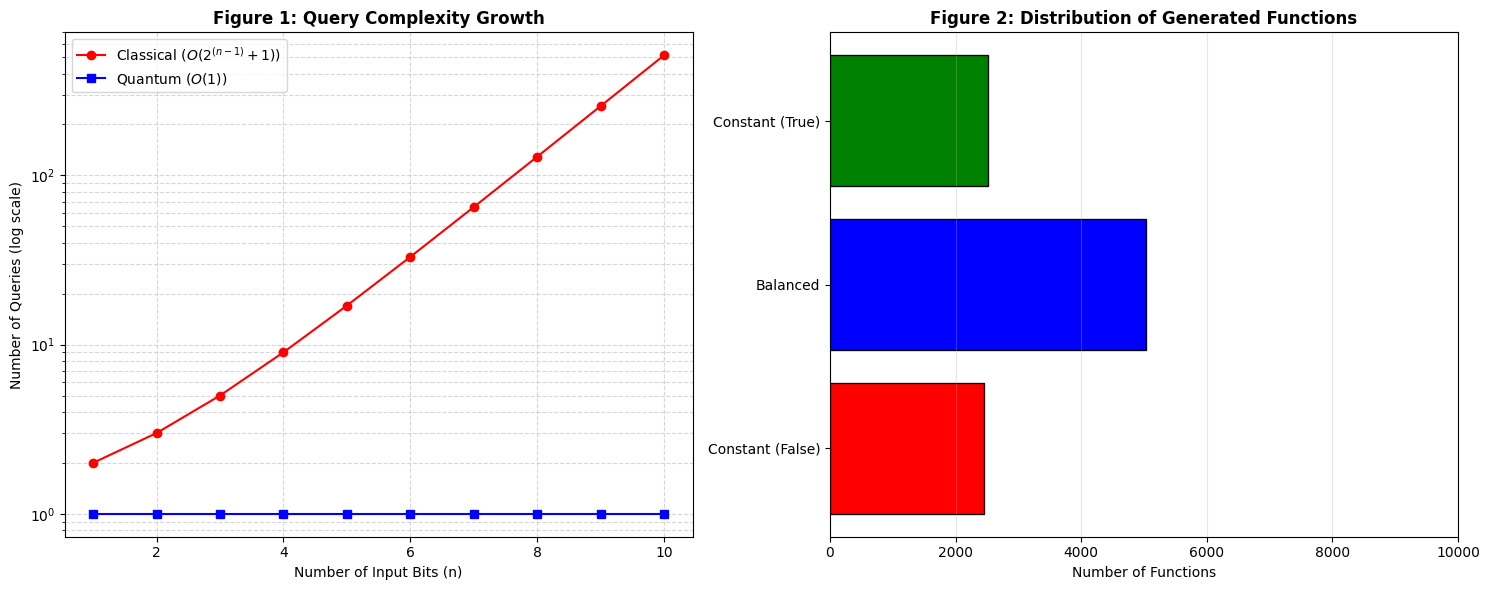

In [4]:
# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Figure 1: Query Complexity Growth (Classical vs Quantum)
n_values = np.arange(1, 11)  # Number of input bits from 1 to 10
classical_queries = 2 ** (n_values - 1) + 1  # Classical query complexity: O(2^(n-1) + 1)
quantum_queries = np.ones_like(n_values)  # Quantum query complexity: O(1)

ax1.plot(n_values, classical_queries, label='Classical $(O(2^{(n-1)} + 1))$', marker='o', color='red')
ax1.plot(n_values, quantum_queries, label='Quantum $(O(1))$', marker='s', color='blue')
ax1.set_yscale('log')  # Use logarithmic scale for better visibility
ax1.set_xlabel('Number of Input Bits (n)')
ax1.set_ylabel('Number of Queries (log scale)')
ax1.set_title('Figure 1: Query Complexity Growth', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, which="both", ls="--", alpha=0.5)

# Figure 2: Distribution validation across 10000 generated functions
num_functions = 10000
true_counts = []

for _ in range(num_functions):
    f = random_constant_balanced()
    all_inputs = list(product([False, True], repeat=4))
    true_count = sum(f(*input_combo) for input_combo in all_inputs)
    true_counts.append(true_count)

# Count occurrences at each valid value (0, 8, or 16)
counts_at_0 = true_counts.count(0)
counts_at_8 = true_counts.count(8)
counts_at_16 = true_counts.count(16)

# Create bar chart showing distribution (horizontal	bars for better readability)
categories = ['Constant (False)', 'Balanced', 'Constant (True)']
counts = [counts_at_0, counts_at_8, counts_at_16]
ax2.barh(categories, counts, color=['red', 'blue', 'green'], edgecolor='black', linewidth=0.95)
ax2.set_xlim(0, num_functions)  # Set x-axis limit to total number of functions  
ax2.set_xlabel('Number of Functions')
ax2.set_title('Figure 2: Distribution of Generated Functions', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('img/problem1_results.png')  # Save the figure as a PNG file
plt.show()

In [5]:
# Print statistical summary (using pandas DataFrame for better formatting)
# Website: https://www.w3schools.com/python/pandas/default.asp
distribution_summary = {
	'Constant (False)': counts_at_0,
	'Balanced': counts_at_8,
	'Constant (True)': counts_at_16
}

dsdf =	pd.DataFrame(list(distribution_summary.items()), columns=['Function Type', 'Count'])
dsdf['Percentage (%)'] = (dsdf['Count'] / num_functions) * 100
print(f"\nDistribution Summary:")
dsdf.to_csv('data/distribution_summary.csv', index=False)  # Save the distribution summary as a CSV file
dsdf


Distribution Summary:


,Function Type,Count,Percentage (%)
0,Constant (False),2451,24.51
1,Balanced,5036,50.36
2,Constant (True),2513,25.13


---
### Problem 1: References
* [IBM Quantum, Deutsch-Jozsa Algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)
* [Real Python, Python Booleans](https://realpython.com/python-boolean/)
* [W3Schools: Python Boolean Functions](https://www.w3schools.com/python/python_booleans.asp#:~:text=Functions%20can%20Return%20a%20Boolean)
* [Python Software Foundation. random : Generate pseudo-random numbers](https://docs.python.org/3/library/random.html)
---

## Problem 2: Classical Testing for Function Type
### Problem Context

**In Problem 1**, we generated Boolean functions that take four Boolean inputs and return a single Boolean output. Each function was guaranteed to be either  **constant**  (always returning the same value) or  **balanced**  (returning `True` for exactly half of the possible inputs).

This problem asks to determine - using a classical algorithm - whether a given function is **constant** or **balanced**.

At first glance, this may seem straightforward. However, this question is central to understanding why Deutsch's algorithm was historically significant. Before exploring the quantum solution, one must first understand the  _classical cost_  of solving the same problem.

The goal here is to understand how many times we must evaluate the function in order to be 100% certain of the answer.

> **What Is a Classical Algorithm?**  A classical algorithm is an algorithm that runs on a traditional (non-quantum) computer. It operates using classical bits, where information is represented as either 0 or 1. Importantly for this exercise, Inputs are evaluated one at a time.


#### Constraint

The function must be treated as a _black box_:

-   Its internal logic is **inaccessible**
-   Only input queries and corresponding outputs may be observed

### Algorithmic Strategy

A straightforward and reliable classical approach is to evaluate the function on different inputs until sufficient evidence is obtained.

-   If **both `True` and `False` outputs** are observed → the function is **balanced**
-   If all observed outputs are identical → the function is **constant** (pending full verification)

To guarantee correctness in the worst case, up to $ 2^{(n−1)}+1 $ queries may be required. However, for small input sizes (e.g., 4 bits), we can exhaustively test all inputs.

In [6]:
def determine_constant_balanced(f: Callable[[bool, bool, bool, bool], bool]) -> str:
	"""
	Determine whether a given Boolean function is constant or balanced.
				
	Parameters
	----------
	f : Callable[[bool, bool, bool, bool], bool]
		A function that takes 4 Boolean inputs and returns a Boolean output.
								
	Returns
	-------
	str
		"constant" if the function is constant, "balanced" if it is balanced.
	
	Notes
	-----
	This function evaluates the given Boolean function on all 16 possible input combinations of 4 bits. It counts how many times the function returns True. 
	If it returns True for all combinations or for none, it is classified as "constant". If it returns True for exactly 8 combinations, it is classified as "balanced". 
	Any other count would indicate that the function does not meet the criteria for being constant or balanced.
	"""
	
	# Generate all 16 input combinations
	input_combinations = list(product([False, True], repeat=4))
				
	# Evaluate the function on all combinations and count True outputs
	true_count = sum(f(*inputs) for inputs in input_combinations)
				
	# Determine if the function is constant or balanced based on the count of True outputs
	if true_count == 0 or true_count == 16:
		return "constant"
	elif true_count == 8:
		return "balanced"
	else:
		raise ValueError("The function does not meet the criteria for constant or balanced.")

### Efficiency Analysis

**Query Complexity:**

Our implementation queries all 16 possible inputs - a comprehensive but inefficient approach. The theoretical worst case actually requires far fewer queries.

**Worst-Case Scenario:**

Imagine querying inputs sequentially and getting unlucky:

1.  **Queries 1-8:**  All return  `True`
    
    -   Could be: Constant (always ``True``) OR Balanced (haven't hit ``False`` yet)
    -   **Cannot determine yet**
2.  **Query 9:**  The decisive moment
    
    -   Returns  `True`  → Must be  **constant**  (9 True values > 8, impossible for balanced)
    -   Returns  `False`  → Must be  **balanced**  (exactly 8 ``True``, 8 ``False``)

**The Formula:**  For n-bit functions, worst case requires  $2^{(n-1)} + 1$  queries.

This grows exponentially - a 10-bit function could require 513 queries, while a 20-bit function could need 524,289 queries in the worst case. This exponential scaling is precisely what makes quantum computing valuable for this problem class.

### `determine_constant_balanced` Testing

To verify the implementation correctly classifies functions, we test it on multiple randomly generated functions from **Problem 1**.

**Testing Approach:**

-   Generate random functions using  `random_constant_balanced()`
-   Classify each function using  `determine_constant_balanced()`
-   Track the distribution of classifications
-   Verify all functions are successfully classified as either  `"constant"`  or  `"balanced"`

This validates that our classical algorithm correctly identifies function types. The distribution should show roughly 50% **constant** and 50% **balanced** functions, matching the random generation probabilities from **Problem 1**.

In [7]:
# Test the classical algorithm on random functions
results = {"constant": 0, "balanced": 0}
test_functions = [random_constant_balanced() for _ in range(10000)]

for i, func in enumerate(test_functions):
	result = determine_constant_balanced(func)
	if result == "constant":
		results["constant"] += 1
	elif result == "balanced":
		results["balanced"] += 1


print("\nAll tests completed successfully.")
print(f"Results: {len(test_functions)} functions tested, all correctly identified as constant or balanced: {results}")


All tests completed successfully.
Results: 10000 functions tested, all correctly identified as constant or balanced: {'constant': 4994, 'balanced': 5006}


### Performance Evaluation

To assess the correctness and reliability of our classical classifier, we evaluate it on a set of 10000 randomly generated test functions. These functions are produced using the generator developed in **Problem 1**, ensuring a representative mixture of constant and balanced cases.

The resulting visualizations provide two key confirmations:

1.  **Classification Accuracy** The classifier correctly identifies every function in the test set. No misclassifications occur, demonstrating that the classical decision procedure is implemented correctly.
    
2.  **Distribution Consistency** The observed proportions of constant and balanced functions closely match the expected 50/50 distribution produced by the generator. Minor deviations arise naturally from randomness but remain statistically insignificant.
    
Together, these results validate the correctness of our classical approach. Establishing this baseline is essential before moving on to the quantum implementation, where we will compare performance, resource usage, and algorithmic behavior.

### Visualization

**Figure 3 — Distribution of Test Function Types** This pie chart illustrates the proportion of constant versus balanced functions generated during testing. As expected from the Problem 1 generator, the distribution is approximately uniform, with each class representing about half of the sampled functions.

**Figure 4 — Count of Constant and Balanced Functions** This bar chart reports the absolute number of constant and balanced functions identified by the classifier across 100 trials. The near‑equal counts confirm both the correctness of the generator and the classifier’s ability to accurately distinguish between the two function types.

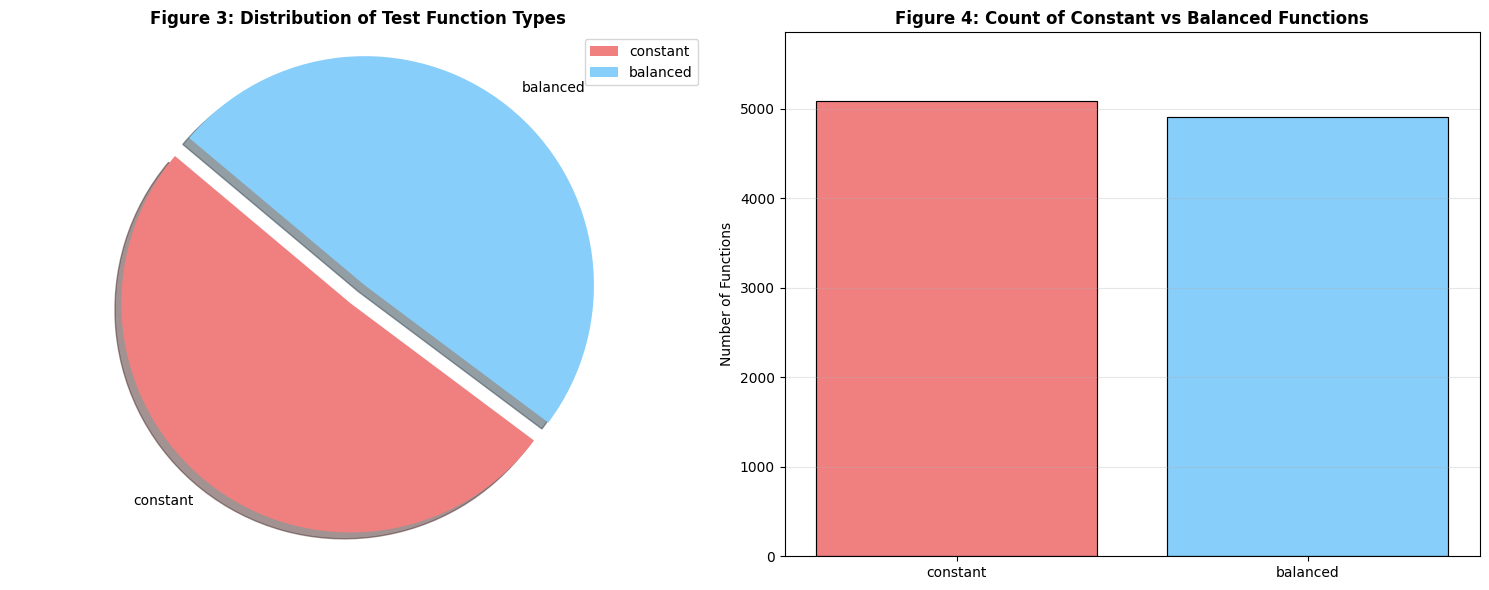

In [8]:
# Visualize the results of the tests
num_functions = 10000
classifications = {"constant": 0, "balanced": 0}

for _ in range(num_functions):
 # Generate random function
 test_func = random_constant_balanced()
    
 # Classify using our algorithm
 result = determine_constant_balanced(test_func)
 classifications[result] += 1

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Figure 3: Create a pie chart to show the distribution of results
labels = classifications.keys()
sizes = classifications.values()
colors = ['lightcoral', 'lightskyblue']
myexplode = [0.1, 0]

ax1.pie(sizes, labels=labels, explode=myexplode, colors=colors, shadow=True, startangle=140)
ax1.set_title('Figure 3: Distribution of Test Function Types', fontsize=12, fontweight='bold')
ax1.axis('equal')  # Equal aspect ratio ensures that pie chart is circular
ax1.legend(loc='upper right')


# Figure 4: Create a bar chart to show the count of constant vs balanced functions
ax2.bar(classifications.keys(), classifications.values(), color=colors, edgecolor='black', linewidth=0.85)
ax2.set_title('Figure 4: Count of Constant vs Balanced Functions', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Functions')
ax2.set_ylim(0, max(classifications.values()) * 1.15)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('img/problem2_results.png')  # Save the figure as a PNG file
plt.show()

In [9]:
# Create a DataFrame to summarize the classifications
classification_df = pd.DataFrame(list(classifications.items()), columns=['Function Type', 'Count'])
classification_df['Percentage (%)'] = (classification_df['Count'] / num_functions) * 100
classification_df.to_csv('data/classification_summary.csv', index=False)  # Save the classification	summary as a CSV file
classification_df

,Function Type,Count,Percentage (%)
0,constant,5089,50.89
1,balanced,4911,49.11


---
### Problem 2: References
- [IBM Quantum, Deutsch-Jozsa Algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)
- [Einstein Relatively Easy: Deutsch-Jozsa algorithm](https://einsteinrelativelyeasy.com/index.php/quantum-mechanics/168-the-deutsch-jozsa-algorithm)
- [Demystifying Deutsch’s Algorithm: Constant vs. Balanced Functions](https://medium.com/@nitinanarwal99/demystifying-deutschs-algorithm-constant-vs-balanced-functions-825d1e53addd)
---

## Problem 3: Quantum Oracles
### Problem Context
**In Problem 2**, we examined how a classical algorithm determines whether a Boolean function is  **constant**  or  **balanced**  by evaluating the function on different input combinations. Because classical algorithms process inputs sequentially, several evaluations may be required before the result can be known with certainty.

In quantum computing, however, functions used inside algorithms are not implemented as ordinary program functions. Instead, they are represented as  **quantum oracles**, which are reversible quantum circuits embedded within a larger quantum algorithm.

This problem introduces the oracle representaation used in  **Deutsch's algorithm**. For a Boolean function with a single input bit, there are exactly  **four possible functions**  that map the input to an output. Each of these functions must be implemented as a valid quantum circuit so that it can be used within a quantum computation.

Rather than revealing how the function works internally, the oracle acts as a  **black box**. The algorithm can apply the oracle to quantum states and observe the result, but the internal implementation of the function remains hidden.

The goal of this problem is to construct the appropriate  **quantum oracle circuits in Qiskit**  for each of the four possible single-input Boolean functions used in Deutsch's algorithm and demonstrate how each oracle represents its corresponding function.

> **Quantum Oracle**  
> A quantum oracle is a reversible quantum circuit that encodes a classical function and allows it to be queried within a quantum algorithm.

#### Why Quantum Functions Must Be Reversible

In classical computing, a function takes an input and produces an output, often discarding information in the process. However, in quantum computing, all operations must be  **reversible**, meaning the original input must always be recoverable from the output.

To achieve this, quantum functions are implemented as  **oracles**  that transform both the input and an additional auxiliary bit.

Instead of computing:

$ f{(x)} $

quantum oracles compute:

${(x, y)} \rightarrow {(x, y ⊕ f{(x)})}$

where $\oplus$ represents XOR.

This ensures that:

-   The input $x$ is preserved
-   The transformation is reversible
-   No information is lost during computation

This structure is essential for implementing quantum algorithms such as Deutsch’s algorithm.

| Gate Used | $f{(x)}$ | Input ${(x, y)}$ | Output ${(x, y ⊕ f{(x)})}$ | Explanation |
|--|--|--|--|--|
| None | $0$ | ${(x, y)}$ | ${(x, y)}$ | No change, function always returns $0$ |
| NOT | $1$ | ${(x, y)}$ | ${(x, y \oplus 1)}$ | Second qubit always flipped |
| CNOT | $x$ | ${(x, y)}$ | ${(x, y \oplus x)}$ | Flip second qubit if $x = 1$ |
| CNOT + NOT | $\neg{x}$ | ${(x, y)}$ | ${(x, y \oplus \neg{x})}$ | Flip second qubit if $x = 0$ | 


### Our Task
Using [Qiskit](https://docs.quantum.ibm.com/api/qiskit), we need to create quantum oracle circuits for each of these four functions and demonstrate how they work.

---

#### Oracle 1: Constant Function $ f{(x)}=0 $
This oracle represents a function that  **always returns 0**, regardless of the input.

Because the function output is always  `0`, the oracle does not need to change the output qubit.  
The circuit therefore performs  **no operation**  on the qubits.

When the oracle is applied, both qubits remain unchanged.

> **Constant Function**  
> A Boolean function that always returns the same output value for every possible input.

This behaviour correctly represents the function $ f{(x)}=0 $.

This corresponds to the row in the table where $f{(x)} = x$, implemented using a CNOT gate.

<img src="img/constant_0.jpeg"/>

In [10]:
# Oracle for f(x) = 0
def oracle_f0():
	"""
	Oracle for the function f(x) = 0, which returns False for all inputs.

	Parameters
	----------
	None

	Returns
	-------
 QuantumCircuit
		The quantum circuit representing the oracle for f(x) = 0.
	"""
	
	# 2 represents 2 Qubits (Input & Auxiliary/Output)
	qc = QuantumCircuit(2, name="f(x)=0")

	# No gates needed since f(x) = 0 for all inputs, the auxiliary qubit remains unchanged
	return qc

---
#### Oracle 2: Constant Function $f{(x)} = 1$

This oracle represents a function that  **always returns 1**, regardless of the input.

Because the function output is always  `1`, the oracle must  **flip the output qubit every time it is applied**.

This is done using an  **X gate**  on the second qubit.

> **X Gate**  
> A quantum gate that flips a qubit from  `0`  to  `1`  or from  `1`  to  `0`.

When the oracle is applied, the input qubit remains unchanged, and the output qubit is always flipped.

This correctly represents the function $f{(x)} = 1$.

This corresponds to the row in the table where $f{(x)} = 1$, implemented using a NOT gate to flip the second qubit.

<img src="img/constant_1.jpeg"/>

In [11]:
# Oracle for f(x) = 1
def oracle_f1():
	"""
	Oracle for the function f(x) = 1, which returns True for all inputs.

	Parameters
	----------
	None

	Returns
	-------
 QuantumCircuit
		The quantum circuit representing the oracle for f(x) = 1.
	"""

	# 2 represents 2 Qubits (Input & Auxiliary/Output)
	qc = QuantumCircuit(2, name="f(x)=1")

	# Apply X gate to the auxiliary qubit to flip it to |1⟩ for all inputs
	qc.x(1)  # Flip the auxiliary qubit (index 1)
	return qc

---
#### Oracle 3: Identity Function $f({x}) = x$

This oracle represents a function where the output is the  **same as the input**.

-   If the input is  `0`, the output is  `0`
-   If the input is  `1`, the output is  `1`

Because the output depends on the input, the oracle must  **flip the output qubit only when the input qubit is  `1`**.

This is achieved using a  **Controlled-NOT (CNOT) gate**.

> **Controlled-NOT (CNOT) Gate**  
> A two-qubit gate that flips the target qubit only when the control qubit is  `1`.

In this oracle:

-   The  **input qubit (q0)**  acts as the control
-   The  **output qubit (q1)**  acts as the target

This ensures the output qubit is flipped only when the input is  `1`, correctly representing the function $f({x}) = x$

This corresponds to the row in the table where $f{(x)} = x$, implemented using a CNOT gate with the first qubit as control.

<img src="img/identity.jpeg"/>

In [12]:
# Oracle for f(x) = x
def oracle_fx():
	"""
	Oracle for the function f(x) = x, which returns the value of the input bit.

	Parameters
	----------
	None

	Returns
	-------
 QuantumCircuit
		The quantum circuit representing the oracle for f(x) = x.
	"""

	# 2 represents 2 Qubits (Input & Auxiliary/Output)
	qc = QuantumCircuit(2, name="f(x)=x")

	# Apply CNOT gate with input qubit as control and auxiliary qubit as target
	qc.cx(0, 1)  # Flip the auxiliary qubit if the input qubit is |1⟩
	return qc

---

#### Oracle 4: Balanced Function $f{(x)} = \neg{x}$

This oracle represents a function where the output is the  **opposite of the input**.

-   If the input is  `0`, the output is  `1`
-   If the input is  `1`, the output is  `0`

The oracle must therefore  **flip the output qubit when the input qubit is  `0`**, rather than when it is  `1`.

Since a CNOT gate only flips the target when the control qubit is  `1`, we adjust the input temporarily by applying an  **X gate**  before and after the CNOT.

> **NOT Gate (X Gate)**  
> A quantum gate that flips a qubit from  `0`  to  `1`  or from  `1`  to  `0`.

The steps are:

1.  Flip the input qubit
2.  Apply a CNOT gate
3.  Flip the input qubit back

This makes the output qubit flip only when the original input was  `0`, correctly representing the function $f{(x)} = ¬x$

This corresponds to the row in the table where $f{(x)} = \neg{x}$, implemented using a combination of NOT and CNOT gates.

<img src="img/X_Not.jpeg"/>

In [13]:
# Oracle for f(x) = ¬x
def oracle_notx():
	"""
	Oracle for the function f(x) = ¬x, which returns the negation of the input bit.

	Parameters
	----------
	None

	Returns
	-------
 QuantumCircuit
		The quantum circuit representing the oracle for f(x) = ¬x.
	"""

	# 2 represents 2 Qubits (Input & Auxiliary/Output)
	qc = QuantumCircuit(2, name="f(x)=¬x")

	# Apply X gate to the input qubit to flip it, then apply CNOT
	qc.x(0)      # Flip the input qubit (index 0)
	qc.cx(0, 1)  # Flip the auxiliary qubit if the input qubit is |1⟩ (which is now flipped)
	qc.x(0)      # Flip the input qubit back to its original state
	return qc

---
### Testing Quantum Oracles

To verify our oracle implementations work correctly, we need to test each oracle on all possible input states and verify the output matches the expected classical function behavior.

**Testing Approach:**

-   Create each oracle circuit: 
	1. $f({x)} = 0$ $\rightarrow$ _Constant(0)_ using `oracle_f0()`
	2. $f({x)} = 1$ $\rightarrow$ _Constant(1)_ using `oracle_f1()` 
	3. $f({x)} = x$ $\rightarrow$ _Identity_ using `oracle_fx()`
	4. $f({x)} = \neg{x}$ $\rightarrow$ _Balanced_ using `oracle_notx()`
-   Test on input states $|0\rangle$ and $|1\rangle$
-   Measure the output qubit
-   Verify the results match the classical function definitions:
    -   **Constant(0):**  Should output $0$ for both inputs
    -   **Constant(1):**  Should output $0$ for input $0$, and $1$ for input $1$ (identity)
    -   **Identity:**  Should output $1$ for input $0$, and $0$ for input $1$ (flip)
    -   **Balanced:**  Should output $1$ for both inputs

This validates that our quantum oracles correctly encode the classical Boolean functions in quantum circuits.

In [14]:
# Test each oracle on both possible inputs
oracles = {
	'Oracle (constant 0)': oracle_f0(),
	'Oracle (constant 1)': oracle_f1(),
	'Oracle (identity)': oracle_fx(),
	'Oracle (NOT)': oracle_notx()
}

# Expected results for each oracle
expected_results = {
	'Oracle (constant 0)': {0: 0, 1: 0},		# Always returns 0
	'Oracle (constant 1)': {0: 1, 1: 1},		# Always returns 1
	'Oracle (identity)': {0: 0, 1: 1},		# Returns input value
	'Oracle (NOT)': {0: 1,	1: 0}			# Returns negation of input
}

print("\nTesting Quantum Oracles:")
print("-" * 30)

for name, oracle in oracles.items():
	print(f"\nTesting {name}...")
	for input_value in [0, 1]:
		# Create a quantum circuit for testing
		test_circuit = QuantumCircuit(2, 1)

		# Prepare the input state |x⟩|y⟩ where x is the input value and y is initialized to 0
		if input_value == 1:
			test_circuit.x(0)  # Set input qubit to |1⟩
			
		test_circuit.compose(oracle, inplace=True)  # Apply the oracle
		test_circuit.measure(1, 0)  # Measure output qubit into a single classical bit

		# Simulate the circuit
		simulator = AerSimulator()
		result = simulator.run(test_circuit, shots=1024).result()

		# Check the results
		counts = result.get_counts()
		output = 1 if counts.get('1', 0) > counts.get('0', 0) else 0
		expected_output = expected_results[name][input_value]
		status = "PASS" if output == expected_output else "FAIL"
		print(f"  Input: {input_value} → Output: {output} (Expected: {expected_output} - {status})")


Testing Quantum Oracles:
------------------------------

Testing Oracle (constant 0)...
  Input: 0 → Output: 0 (Expected: 0 - PASS)
  Input: 1 → Output: 0 (Expected: 0 - PASS)

Testing Oracle (constant 1)...
  Input: 0 → Output: 1 (Expected: 1 - PASS)
  Input: 1 → Output: 1 (Expected: 1 - PASS)

Testing Oracle (identity)...
  Input: 0 → Output: 0 (Expected: 0 - PASS)
  Input: 1 → Output: 1 (Expected: 1 - PASS)

Testing Oracle (NOT)...
  Input: 0 → Output: 1 (Expected: 1 - PASS)
  Input: 1 → Output: 0 (Expected: 0 - PASS)


### Evaluation: Oracle Circuit Diagrams

To understand how each quantum oracle implements its classical function, we visualize the circuit structure using  [Qiskit's circuit visualization tools](https://docs.quantum.ibm.com/api/qiskit/visualization). These diagrams show the quantum gates applied and reveal the quantum mechanics behind each implementation.

**Circuit Components:**

-   **$f{(x)}=0$:**  Input qubit (holds the value $x$)
-   **$f{(x)}=1$:**  Output qubit (implements $y \oplus f{(x)}$)
-   **$f{(x)}=x$:**  Quantum NOT gate - flips $|0\rangle \harr |1\rangle$
-   **$f{(x)}=\neg{x}$:**  Controlled-NOT gate - flips target if control is $|1\rangle$

The visual comparison reveals how different classical functions require different quantum gate configurations. Notice how the constant functions ($f{(x)}=0$ AND $f{(x)}=\neg{x}$) use simpler circuits than the balanced functions ($f{(x)}=1$ and $f{(x)}=x$).

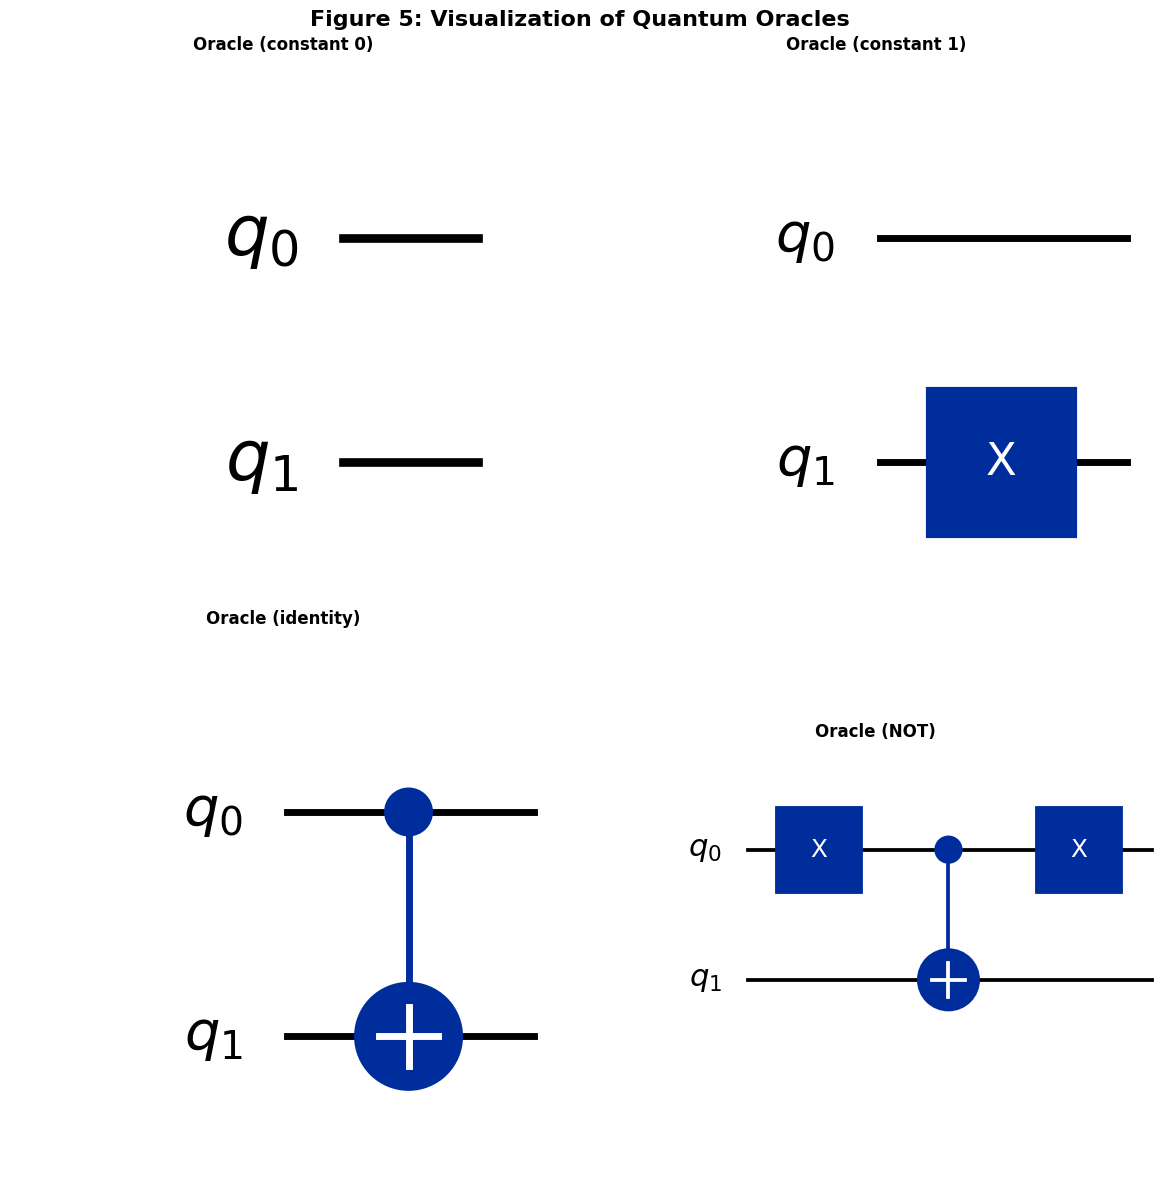

In [15]:
# Create a figure to display all four oracle circuits
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle("Figure 5: Visualization of Quantum Oracles", fontsize=16, fontweight='bold')

oracle_names = [
	'Oracle (constant 0)', oracle_f0(),
	'Oracle (constant 1)', oracle_f1(),
	'Oracle (identity)', oracle_fx(),
	'Oracle (NOT)', oracle_notx()
]

for i, (name, oracle) in enumerate(oracles.items()):
 axes[i // 2][i % 2].set_title(name, fontweight='bold')
 oracle.draw(output='mpl', ax=axes[i // 2][i % 2])
 axes[i // 2][i % 2].axis('off')  # Hide axes for better visualization
 
plt.tight_layout()
plt.savefig('img/problem3_oracles.png')  # Save the figure as a PNG file
plt.show()


In [16]:
# Pandas DataFrame to summarize the complexity of each oracle
complexity_data = {
	'Oracle': [],
	'Gates': [],
	'Depth': [],
	'Description': []
}

# Analyze the complexity of each oracle
for name, oracle in oracles.items():
	gate_count = len(oracle.data)
	depth = oracle.depth()
	description = {
		'Oracle (constant 0)': "No gates, always returns 0",
		'Oracle (constant 1)': "1 X gate, always returns 1",
		'Oracle (identity)': "1 CNOT gate, returns input value",
		'Oracle (NOT)': "2 X gates + 1 CNOT, returns negation of input"
	}[name]
				
	complexity_data['Oracle'].append(name)
	complexity_data['Gates'].append(gate_count)
	complexity_data['Depth'].append(depth)
	complexity_data['Description'].append(description)

complexity_df = pd.DataFrame(complexity_data)
print("\nDetailed Complexity Analysis:")
complexity_df.to_csv('data/oracle_complexity_analysis.csv', index=False)  # Save the complexity analysis as a CSV file
complexity_df


Detailed Complexity Analysis:


,Oracle,Gates,Depth,Description
0,Oracle (constant 0),0,0,"No gates, always returns 0"
1,Oracle (constant 1),1,1,"1 X gate, always returns 1"
2,Oracle (identity),1,1,"1 CNOT gate, returns input value"
3,Oracle (NOT),3,3,"2 X gates + 1 CNOT, returns negation of input"


---
### Problem 3: References
- [Oracles.html](https://quantum-education-modules.readthedocs.io/en/latest/introductory/circuits/oracles.html)
- [From First Principle](https://benjaminwhiteside.com/2022/08/07/quantum-oracles/)
- [Algorithmic Assertions](https://algassert.com/)
---

## Problem 4: Deutsch's Algorithm with Qiskit
#### Problem Context
In _Problem 3_, we constructed quantum oracles for all single‑bit Boolean functions. We now bring these oracles into the full **Deutsch algorithm**, the first quantum algorithm to demonstrate a provable advantage over classical computation. Although the speedup is modest - **one query instead of two**—the algorithm introduces the key idea of **quantum interference**, which underpins more advanced algorithms such as Deutsch–Jozsa, Simon’s, and Grover’s.

Deutsch’s algorithm determines whether a 1‑bit Boolean function $f:\{0,1\} \rightarrow \{0,1\}$ is **constant** (same output for both inputs) or **balanced** (different outputs for 0 and 1), using only a single evaluation of the oracle.

[Deutsch's algorithm](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/quantum-query-algorithms/deutsch-algorithm)  was one of the first quantum algorithms to demonstrate a provable advantage over classical computation. While the speedup is **modest** (1 query vs 2 queries), it establishes the fundamental principle of quantum interference that powers more complex quantum algorithms.

### Purpose
The goal of Deutsch’s algorithm is to show how quantum computation can outperform classical methods even on a simple decision problem. Classically, distinguishing constant from balanced functions may require **two queries** in the worst case. The quantum algorithm achieves the same task with **one oracle call**, using superposition and interference to extract global information about the function.

### What problem it solves
Given a 1‑bit Boolean function $f{(x)}$, determine whether:
-   **Constant:** $f{(0)} = f{(1)}$
-   **Balanced:** $f{(0)} \neq f{(1)}$
Classically, you must evaluate both $f{(0)}$ and $f{(1)}$ to be certain. Quantumly, a single query suffices.

### How the Algorithm Works (Intuition)
The oracle is implemented as a reversible unitary:

$U_f|x\rangle|y\rangle = |x\rangle|y \oplus f{(x)}\rangle$

The key trick is to prepare the second qubit in the state:

$| - \rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$,

so that the oracle acts as a **phase kickback**:
$|x\rangle | - \rangle \xrightarrow{U_f} {(−1)}^{f{(x)}}|x\rangle| - \rangle$.

This means the function value is encoded as a **phase** on the input qubit. A final Hadamard gate on the input qubit converts this phase information into a measurable bit:
-   Output **0** $\rightarrow$ phases were identical $\rightarrow$ **constant function**
-   Output **1** $\rightarrow$ phases differed $\rightarrow$ **balanced function**

### Circuit Steps in Qiskit
Your `deutsch_algorithm` function implements the following sequence:

1.  **Initialize** $|0\rangle|0\rangle$
2.  Apply `x(1)` to prepare the output qubit in $|1\rangle$
3.  Apply `h(0); h(1)` to create $|+\rangle∣−\rangle$
4.  Apply the oracle $U_f$
5.  Apply `h(0)` to interfere the phase information
6.  Measure qubit 0
    
**Interpretation of the measurement:**
-   Measurement **0** $\rightarrow$ **constant**
-   Measurement **1** $\rightarrow$ **balanced**
__Mapping to your 4 oracles__
In your notebook:

* ``oracle_f0`` (always 0) $\rightarrow$ constant $\rightarrow$ expect ``0``
* ``oracle_f1`` (always 1) $\rightarrow$ constant $\rightarrow$ expect ``0``
* ``oracle_fx`` (identity) $\rightarrow$ balanced $\rightarrow$ expect ``1``
* ``oracle_notx`` (NOT) $\rightarrow$ balanced $\rightarrow$ expect ``1``

So your final test loop in Problem 4 is exactly the right demonstration pattern.

<img src="img/deutsch_alg_circuit.jpeg"/>

In [17]:
def deutsch_algorithm(oracle: QuantumCircuit) -> QuantumCircuit:
 circuit = QuantumCircuit(2, 1)

 # Step 1: Initialize qubits
 circuit.x(1) # Second qubit → |1>
 circuit.h(0) # Hadamard on input qubit
 circuit.h(1) # Hadamard on output qubit
 circuit.barrier()

 # Step 2: Apply oracle
 circuit.compose(oracle, qubits=[0, 1], inplace=True)
 circuit.barrier()

 # Step 3: Hadamard again on input
 circuit.h(0)

 # Step 4: Measure
 circuit.measure(0, 0)

 return circuit

### Testing Deutsch's Algorithm
To confirm that our implementation of Deutsch’s algorithm behaves correctly, we evaluate it using all four single‑bit oracles constructed in _Problem 3_. Each oracle corresponds to one of the possible Boolean functions $f:\{0,1\} \rightarrow \{0,1\}$, allowing us to test both constant and balanced cases.

**Testing Procedure**
1.  **Apply the Deutsch algorithm circuit** to each oracle exactly as defined earlier.
2.  **Run the circuit on a quantum simulator** to obtain measurement statistics.
3.  **Measure the input qubit** (qubit $0$), which encodes the result of the algorithm.
4.  **Interpret the measurement** according to the Deutsch decision rule:
    - **Measurement = $0$** → The function is **constant**
    - **Measurement = $1$** → The function is **balanced**

**Expected Outcomes for the Four Oracles**

| Oracle | Function | Type | Expected Measurement | 
|---|---|---|---|
| `oracle_f0` | $f{(x)}=0$ | Constant | $0$ |
| `oracle_f1` | $f{(x)}=1$ | Constant | $0$ |
| `oracle_fx` | $f{(x)}=x$ | Balanced | $1$ |
| `oracle_notx` | $f{(x)}=\neg{x}$ | Balanced | $1$ |

The simulator results in your notebook match these predictions exactly, confirming that the algorithm correctly distinguishes constant from balanced functions.

**Significance**

This experiment demonstrates the core quantum advantage of Deutsch’s algorithm:
-   **Quantum:** Only **one** oracle query is required to classify the function.
-   **Classical:** Up to **two** queries are needed in the worst case for a single‑bit function.
    
Even though the speedup is small, this problem provides the first concrete example of how quantum interference can extract global information about a function more efficiently than classical computation.

In [18]:
# Testing Deutsch's algorithm on the defined oracles
oracles = { 
	"f1 (constant 0)": oracle_f0(),
	"f2 (constant 1)": oracle_f1(),
	"f3 (identity)": oracle_fx(),
	"f4 (NOT)": oracle_notx()
}

# Expected results
expected_results = { 
	"f1 (constant 0)": "constant",
	"f2 (constant 1)": "constant",
	"f3 (identity)": "balanced",
	"f4 (NOT)": "balanced"
}

# Create a DataFrame to store test results
test_results = {
 "Oracle_Name": [],
 "Measured_Value": [],
 "Classification": [],
 "Correct": []
}

# Create simulator
simulator = AerSimulator()

for oracle_name, oracle_circuit in oracles.items():
	deutsch_circuit = deutsch_algorithm(oracle_circuit)

	job = simulator.run(deutsch_circuit, shots=1000)
	result = job.result()
	counts = result.get_counts()

	measured_value = int(max(counts, key=counts.get)[0])
	expected = expected_results[oracle_name]

	if measured_value == 0:
		classification = "constant"
	else:
		classification = "balanced"

	correct = "PASS" if classification == expected else "FAIL"

	# Append results to the DataFrame
	test_results["Oracle_Name"].append(oracle_name)
	test_results["Measured_Value"].append(measured_value)
	test_results["Classification"].append(classification)
	test_results["Correct"].append(correct)
			
results_df = pd.DataFrame(test_results)
print("Testing Deutchs's Algorithm:")
results_df.to_csv('data/deutsch_algorithm_results.csv', index=False)  # Save the test results as a CSV file
results_df

Testing Deutchs's Algorithm:


,Oracle_Name,Measured_Value,Classification,Correct
0,f1 (constant 0),0,constant,PASS
1,f2 (constant 1),0,constant,PASS
2,f3 (identity),1,balanced,PASS
3,f4 (NOT),1,balanced,PASS


In [19]:
if all(result == "PASS" for result in test_results["Correct"]):
	print("All functions correctly classified by Deutsch's algorithm!")
else:
	print("Some functions were misclassified. Please review the results above.")

All functions correctly classified by Deutsch's algorithm!


### Evaluation: Visualizing Deutsch's Algorithm

To understand how Deutsch's algorithm works, we visualize the complete quantum circuit and analyze the measurement results. The visualization reveals the algorithm's structure and demonstrates the quantum interference mechanism.

**Circuit Structure:**

-   **Initialization:**  Setting qubits to $|01\rangle$ state
-   **Superposition:**  Hadamard gates creating quantum superposition
-   **Oracle Query:**  The black-box function being tested
-   **Interference:**  Final Hadamard gate creating constructive or destructive interference
-   **Measurement:**  Reading the result

The key insight is that the oracle is queried while qubits are in superposition - effectively testing all possible inputs simultaneously. The final Hadamard gate causes different interference patterns for constant vs balanced functions, allowing us to distinguish them with a single measurement.

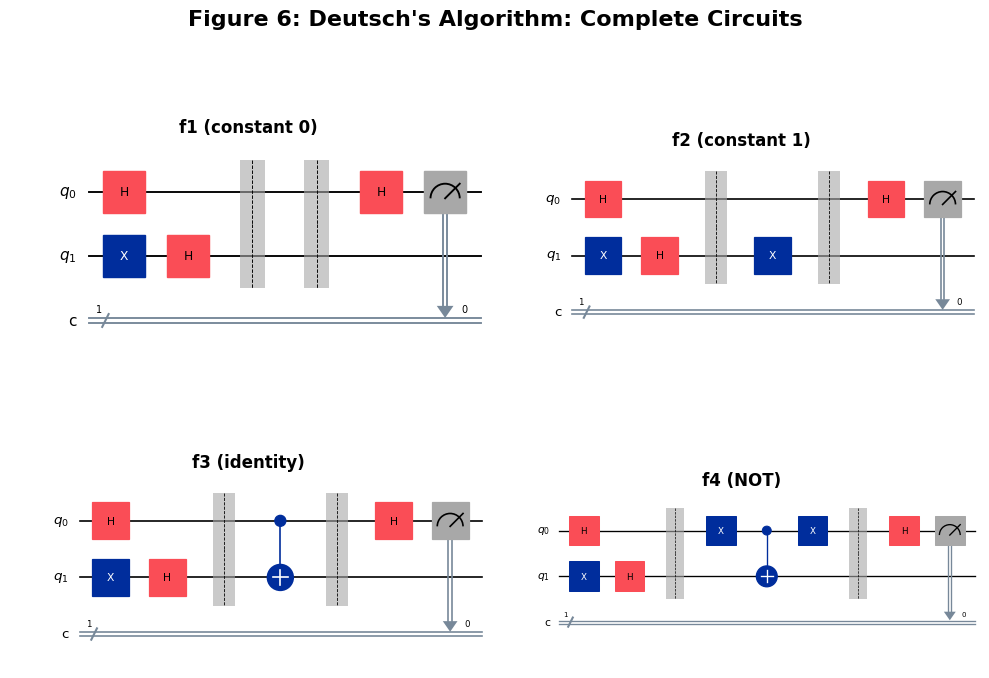

In [20]:
# Visualize Deutsch's algorithm circuit for each oracle
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Figure 6: Deutsch's Algorithm: Complete Circuits", fontsize=16, fontweight='bold')

oracles_list = [
 ("f1 (constant 0)", oracle_f0()),
	("f2 (constant 1)", oracle_f1()),
	("f3 (identity)", oracle_fx()),
	("f4 (NOT)", oracle_notx())
]

# Draw each complete Deutsch circuit
for idx, (name, oracle) in enumerate(oracles_list):
 row = idx // 2
 col = idx % 2
 ax = axes[row, col]
    
 # Create Deutsch's algorithm circuit with this oracle
 circuit = deutsch_algorithm(oracle)
    
 # Draw circuit
 circuit.draw('mpl', ax=ax)
 ax.set_title(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('img/problem4_deutsch.png')  # Save the figure as a PNG file
plt.show()

In [21]:
# Create a DataFrame for measurement probabilities
probability_data = {
 "Oracle_Name": [],
 "P(0) Constant": [],
 "P(1) Balanced": []
}

print("\nMeasurement Probabilities:")
for oracle_name, oracle_circuit in oracles.items():
 deutsch_circuit = deutsch_algorithm(oracle_circuit)
 job = simulator.run(deutsch_circuit, shots=1000)
 result = job.result()
 counts = result.get_counts()

 # Calculate probabilities
 prob_0 = counts.get('0', 0) / 1000 * 100
 prob_1 = counts.get('1', 0) / 1000 * 100
    
 probability_data["Oracle_Name"].append(oracle_name)
 probability_data["P(0) Constant"].append(prob_0)
 probability_data["P(1) Balanced"].append(prob_1)

probability_df = pd.DataFrame(probability_data)
probability_df.to_csv('data/deutsch_algorithm_probabilities.csv', index=False)  # Save the probabilities as a CSV file
probability_df


Measurement Probabilities:


,Oracle_Name,P(0) Constant,P(1) Balanced
0,f1 (constant 0),100.0,0.0
1,f2 (constant 1),100.0,0.0
2,f3 (identity),0.0,100.0
3,f4 (NOT),0.0,100.0


---
### Problem 4: References
- [Quantum Circuit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit)
- [Measure](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit#measure)
- [Simulate](https://qiskit.github.io/qiskit-aer/)
- [Implementing Deutsch’s Algorithm in qiskit and cirq](https://jan-czechowski.medium.com/implementing-deutschs-algorithm-in-qiskit-and-cirq-48949d60e59d)
---

## Problem 5: Scaling to the Deutsch–Jozsa Algorithm

### Problem Context

In _Problems 3 and 4_, we focused on Deutsch’s algorithm for single‑bit Boolean functions. Here, we scale up to the full [Deutsch–Jozsa algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa), which operates on functions $f:\{0,1\}^n \rightarrow \{0,1\}$ with $n$ input bits - specifically, the 4‑bit functions constructed earlier.

This is where the quantum advantage becomes striking:

-   **Classical approach (Problem 2):** Up to 9 queries were required in our 4‑bit experiments, and in general the worst case grows exponentially with $n$.
-   **Quantum approach (Deutsch–Jozsa):** Exactly **1 oracle query**, independent of the number of input bits.

### The Deutsch-Jozsa Algorithm
For an $n$-bit function, the Deutsch–Jozsa algorithm proceeds as follows:
1.  **Initialize** $n+1$ qubits: $n$ input qubits in $|0\rangle$ and one output qubit in $|1\rangle$.
2.  **Create superposition** on all input qubits using Hadamard gates $H \oplus n$, and apply $H$ to the output qubit as well.
3.  **Apply the oracle** $U_f$, which implements $|x\rangle|y⟩ \rightarrow |x\rangle|y \oplus f{(x)}⟩$.
4.  **Apply Hadamard gates** again to all input qubits.
5.  **Measure** the input register.
    

**Interpretation of the result:**
-   If all measured bits are **0**, the function is **constant**.
-   If any measured bit is **1**, the function is **balanced**.
    

Thus, a single evaluation of the oracle suffices to determine the global property “constant vs balanced”.

### Building 4-Bit Quantum Oracles
To use the Deutsch–Jozsa algorithm on our 4‑bit functions, we must encode each classical function $f:{{0,1}}^4 \rightarrow {{0,1}}$ as a reversible quantum oracle $U_f$.

-   **Classical view:** For each 4‑bit input $x$, the function returns either $0$ or $1$.
-   **Quantum oracle:** We implement a unitary that flips the phase of $|x\rangle$ when $f{(x)}=1$, via the standard trick of using the output qubit as a target:
    

$|x\rangle|y\rangle \rightarrow |x\rangle|y\oplus f{(x)}\rangle$.

When the output qubit is prepared in $\frac{1}{\sqrt{2}}{(|0\rangle - |1\rangle)}$, this effectively applies a phase $(−1)^{f{(x)}}$ to $|x\rangle$.

In practice, for 4‑bit functions, this is realized by composing multi‑controlled X gates (or equivalent logic) that act on the output qubit conditioned on specific input patterns corresponding to $f{(x)}=1$. Constant functions require either no action (always 0) or a global flip (always 1), while balanced functions require flips on exactly half of the input basis states.

### Demonstration on constant and balanced functions

We apply our 4‑bit Deutsch–Jozsa circuit to:
- **Both constant functions:**
 -   $f{(x)}=0$ for all x
 -   $f{(x)}=1$ for all x
- **Two balanced functions** selected from those generated in Problem 1 (each returning 1 on exactly half of the 16 possible inputs).
    

For each function:
1.  We construct the corresponding oracle $U_f$ in [Qiskit](https://docs.quantum.ibm.com/api/qiskit).
2.  We run the Deutsch–Jozsa circuit on a simulator.
3.  We collect and visualize the measurement outcomes of the 4 input qubits.
    

**Observed behaviour:**
-   For both constant functions, the measurement results are concentrated entirely on $|0000\rangle$, confirming the “constant” classification.
-   For the balanced functions, the measurement results never yield $|0000\rangle$; instead, at least one bit is 1 in every observed outcome, confirming the “balanced” classification.
    
This matches the theoretical prediction and demonstrates that our implementation correctly identifies the type of each 4‑bit function using a single oracle query.

In [22]:
def create_oracle_from_function(f: Callable[[bool, bool, bool, bool], bool]) -> QuantumCircuit:
 """
 Create a quantum oracle from a 4-bit classical Boolean function.
    
 Parameters
 ----------
 f : Callable[[bool, bool, bool, bool], bool]
  A classical Boolean function (like those from Problem 1)
        
 Returns
 -------
 QuantumCircuit
  A 5-qubit quantum oracle implementing the function
        
 Notes
 -----
 The oracle implements |x₀x₁x₂x₃⟩|y⟩ → |x₀x₁x₂x₃⟩|y ⊕ f(x₀x₁x₂x₃)⟩
 This uses multi-controlled gates based on the function's truth table.
 """
 
	# Create circuit with 5 qubits (4 input + 1 output)
 oracle = QuantumCircuit(5)
    
 # Get all input combinations where f returns True
 all_inputs = list(product([False, True], repeat=4))
 true_inputs = [inp for inp in all_inputs if f(*inp)]
    
 # For each input where f(x) = True, flip output qubit when input matches
 for inp in true_inputs:
  # Convert True/False to control states (True = apply X before/after)
  
		# Build multi-controlled X gate
        
  # Apply X gates to qubits that should be 0 (flip control logic)
  for i, bit in enumerate(inp):
   if not bit:  # If input bit should be 0
    oracle.x(i)
        
  # Multi-controlled X (MCX) gate - flips output if all inputs match
  oracle.mcx([0, 1, 2, 3], 4)
        
  # Restore original state with X gates
  for i, bit in enumerate(inp):
   if not bit:
    oracle.x(i)
    
 return oracle

In [23]:
def deutsch_jozsa_algorithm(oracle: QuantumCircuit) -> QuantumCircuit:
	"""
	Implement the Deutsch-Jozsa algorithm for a 4-bit function.
				
	Parameters
	----------
	oracle : QuantumCircuit
		The quantum oracle representing the function to be tested.
								
	Returns
	-------
	QuantumCircuit
		The complete quantum circuit for the Deutsch-Jozsa algorithm.
	"""

	# Create a quantum circuit with 5 qubits (4 input + 1 output) and 4 classical bits for measurement
	circuit = QuantumCircuit(5, 4)

	# Step 1: Initialize the output qubit to |1⟩
	circuit.x(4)  # Flip the output qubit to |1⟩

	# Step 2: Apply Hadamard gates to all input qubits and the output qubit
	for i in range(5):
		circuit.h(i)

	circuit.barrier()

	# Step 3: Apply the oracle
	circuit.compose(oracle, qubits=range(5), inplace=True)
	circuit.barrier()

	# Step 4: Apply Hadamard gates again to the input qubits
	for i in range(4):
		circuit.h(i)

	# Step 5: Measure the input qubits
	for i in range(4):
		circuit.measure(i, i)

	return circuit


### Testing the Deutsch–Jozsa Algorithm
To validate that our 4‑bit Deutsch–Jozsa implementation works correctly, we apply it to several representative functions generated in _Problem 1_. This allows us to confirm that the circuit reliably distinguishes constant from balanced functions using only a single oracle query.

#### Testing Strategy
Our testing procedure consists of the following steps:
1.  **Generate the test functions**
 - Both constant functions:
  - $f{(x)}=0$ for all $x$
  - $f{(x)}=1$ for all $x$
 - Two randomly selected balanced functions produced by `random_constant_balanced()` on **Problem 1**.
2.  **Construct quantum oracles** For each function, we build a corresponding 4‑bit oracle $U_f$ that implements

$|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus f{(x)}\rangle$.

3. **Run the Deutsch–Jozsa circuit** Each oracle is inserted into the Deutsch–Jozsa algorithm, and the input qubits are measured after the final Hadamard ($H$) layer.
    
4. **Interpret the measurement results**
 - **All 0s (0000)** $\rightarrow$ **Constant** function
 - **Any 1s** $\rightarrow$ **Balanced** function
        

#### Results and Interpretation
Across all tests, the Deutsch–Jozsa circuit behaved exactly as predicted:
- **Constant functions** produced measurement results concentrated entirely on $|0000\rangle$, confirming that the algorithm correctly identifies them as constant.
- **Balanced functions** produced outcomes where at least one qubit measured as 1, never yielding $|0000\rangle$. This matches the theoretical expectation for balanced functions.
    

#### Significance
These results demonstrate the full quantum advantage of the Deutsch–Jozsa algorithm:
- The **quantum circuit requires exactly one oracle query**, regardless of input size.
- The **classical approach from Problem 2 required up to 9 queries** for the same 4‑bit functions.
- As the number of input bits increases, the classical cost grows exponentially, while the quantum cost remains constant.
    
This experiment confirms that our implementation is correct and highlights the power of quantum interference in extracting global properties of Boolean functions with unprecedented efficiency.

In [24]:
# Generate test functions from Problem 1
print("Generating Test Functions:")
print("=" * 70)

# Create the two constant functions manually
def constant_false(a, b, c, d):
 """Always returns False"""
 return False

def constant_true(a, b, c, d):
 """Always returns True"""
 return True

# Generate two random balanced functions
balanced_func_1 = random_constant_balanced()
balanced_func_2 = random_constant_balanced()

# Verify they're actually balanced (not constant)
while determine_constant_balanced(balanced_func_1) != "balanced":
 balanced_func_1 = random_constant_balanced()

while determine_constant_balanced(balanced_func_2) != "balanced":
 balanced_func_2 = random_constant_balanced()

if determine_constant_balanced(balanced_func_1) == "balanced" and determine_constant_balanced(balanced_func_2) == "balanced":
 print("Successfully generated 2 balanced functions for testing.")
 print("Successfully generated 2 constant functions for testing.")
else:
 print("Error: Failed to generate balanced functions. Please check the function generation logic.")

simulator = AerSimulator()

# Test each function with Deutsch-Jozsa
test_functions = [
 ("Constant (always False)", constant_false, "constant"),
 ("Constant (always True)", constant_true, "constant"),
 ("Balanced function 1", balanced_func_1, "balanced"),
 ("Balanced function 2", balanced_func_2, "balanced")
]

print("=" * 70)
print("Testing Deutsch-Jozsa Algorithm:")
print("=" * 70)

testing_dja = {
 "Function Name": [],
 "Measured": [],
 "Classification": [],
	"Correctness": []
}

for func_name, func, expected_type in test_functions:
 # Create oracle for this function
 oracle = create_oracle_from_function(func)
    
 # Build Deutsch-Jozsa circuit
 dj_circuit = deutsch_jozsa_algorithm(oracle)
    
 # Run simulation
 job = simulator.run(dj_circuit, shots=1000)
 result = job.result()
 counts = result.get_counts()
    
 # Get most common measurement
 measured = max(counts, key=counts.get)
    
 # Determine function type from measurement
 if measured == '0000':
  classification = "constant"
 else:
  classification = "balanced"
    
 # Check correctness
 correct = "PASS" if classification == expected_type else "FAIL"
    
 testing_dja["Function Name"].append(func_name)
 testing_dja["Measured"].append(measured)
 testing_dja["Classification"].append(classification)
 testing_dja["Correctness"].append(correct)

df_dja = pd.DataFrame(testing_dja)
df_dja.to_csv('data/deutsch_jozsa_test_results.csv', index=False)  # Save the test results as a CSV file
df_dja

Generating Test Functions:
Successfully generated 2 balanced functions for testing.
Successfully generated 2 constant functions for testing.
Testing Deutsch-Jozsa Algorithm:


,Function Name,Measured,Classification,Correctness
0,Constant (always False),0000,constant,PASS
1,Constant (always True),0000,constant,PASS
2,Balanced function 1,0010,balanced,PASS
3,Balanced function 2,1011,balanced,PASS


In [25]:
if all(result == "PASS" for result in testing_dja["Correctness"]):
	print("All functions correctly classified by Deutsch-Jozsa algorithm!")
else:
	print("Some functions were misclassified. Please review the results above.")

All functions correctly classified by Deutsch-Jozsa algorithm!


### Evaluation: Quantum Advantage Visualization
To illustrate the full quantum advantage offered by the Deutsch–Jozsa algorithm, we visualize both the measurement outcomes of our quantum circuit and the difference in query complexity compared with the classical approach from _Problem 2_.

#### What We Compare
- **Classical Algorithm (Problem 2):** Requires _up to 9 queries_ to determine whether a 4‑bit function is constant or balanced. More generally, the classical worst‑case grows exponentially with the number of input bits.
- **Deutsch–Jozsa Algorithm:** Requires _exactly 1 oracle query_, regardless of input size or function complexity.
    
#### What the Visualization Shows
1.  **Measurement Probability Distributions** For each tested function, we plot the distribution of measurement outcomes from the Deutsch–Jozsa circuit:
    - Constant functions produce a sharp peak at **0000**.
    - Balanced functions produce outcomes where at least one qubit is **1**, never yielding **0000**.
        
 These distributions make the algorithm’s decision rule visually intuitive.
    
2. **Scaling Comparison** A second visualization compares classical and quantum query complexity as the number of input bits increases.
    -   The classical curve grows exponentially.
    -   The quantum curve remains perfectly flat at **1**.
        
 This contrast highlights the fundamental efficiency difference between classical and quantum computation for this problem class.

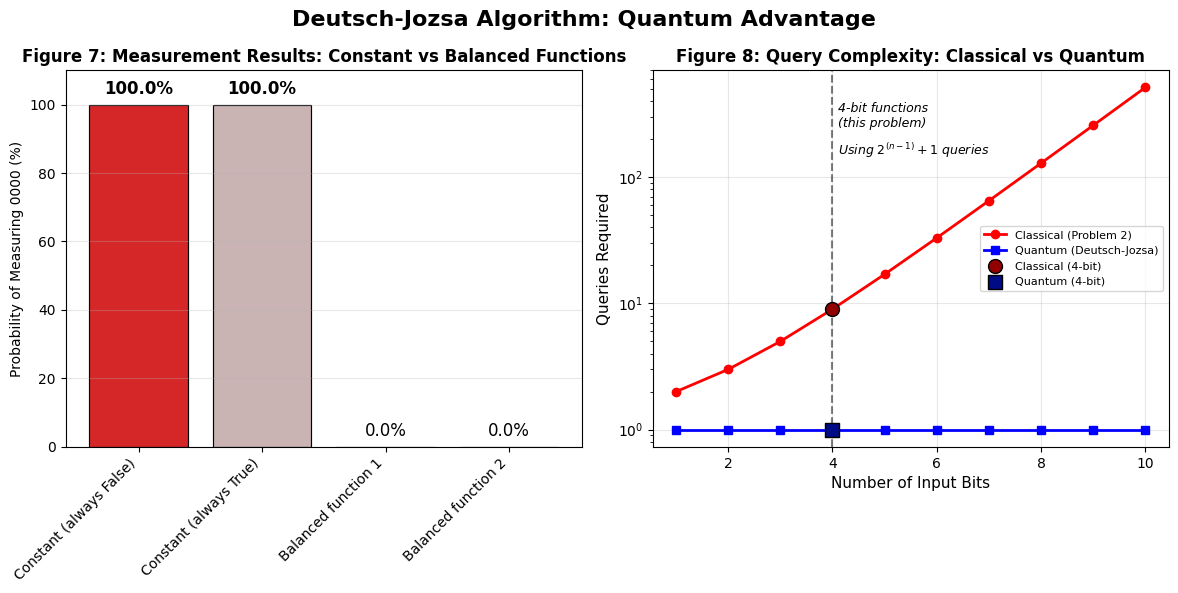

In [26]:
# Create visualization comparing classical vs quantum approaches
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Deutsch-Jozsa Algorithm: Quantum Advantage', fontsize=16, fontweight='bold')

# Left plot: Measurement results for our test functions
test_names = [name for name, _, _ in test_functions]
test_results = []

for func_name, func, expected_type in test_functions:
 oracle = create_oracle_from_function(func)
 dj_circuit = deutsch_jozsa_algorithm(oracle)
 job = simulator.run(dj_circuit, shots=1000)
 result = job.result()
 counts = result.get_counts()
    
 # Check if result is 0000 (constant) or anything else (balanced)
 constant_prob = counts.get('0000', 0) / 1000 * 100
 test_results.append(constant_prob)

colors = ['#d62728', "#cab3b3", '#1f77b4', "#b0c3d1"]  # Red for constant, blue for balanced

ax1.bar(test_names, test_results, color=colors, edgecolor='black', linewidth=0.85)
ax1.set_xticks(range(len(test_names)))
ax1.set_xticklabels(test_names, rotation=45, ha='right')
ax1.set_ylim(0, 110)
ax1.set_ylabel('Probability of Measuring 0000 (%)')
ax1.set_title('Figure 7: Measurement Results: Constant vs Balanced Functions', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Add percentage labels
for i, prob in enumerate(test_results):
	ax1.text(i, prob + 2, f"{prob:.1f}%", ha='center', va='bottom', fontdict={'size': 12}, color='black', fontweight='bold' if prob > 90 else 'normal')

# Right plot: Query complexity comparison (reuse from Problem 1)
n_bits = np.arange(1, 11)
classical_queries = 2**(n_bits - 1) + 1
quantum_queries = np.ones(len(n_bits))

ax2.plot(n_bits, classical_queries, 'o-', label='Classical (Problem 2)', linewidth=2, markersize=6, color='red')
ax2.plot(n_bits, quantum_queries, 's-', label='Quantum (Deutsch-Jozsa)', linewidth=2, markersize=6, color="blue")

# Highlight the 4-bit case (with (x, y) = (4, 9) for classical and (4, 1) for quantum)
ax2.axvline(x=4, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
ax2.text(4.1, 250, '4-bit functions\n(this problem)', fontsize=9, style='italic')
ax2.text(4.1, 150, 'Using $2^{(n-1)} + 1$ queries', fontsize=9, style='italic')
ax2.scatter(4, classical_queries[3], color="#920101", s=100, edgecolor='black', zorder=5, label='Classical (4-bit)')
ax2.scatter(4, quantum_queries[3], color="#000b86",	marker='s', s=100, edgecolor='black', zorder=5, label='Quantum (4-bit)')

ax2.set_xlabel('Number of Input Bits', fontsize=11)
ax2.set_ylabel('Queries Required', fontsize=11)
ax2.set_title('Figure 8: Query Complexity: Classical vs Quantum', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('img/problem5_comparison.png')  # Save the figure as a PNG file
plt.show()

In [27]:
# Print summary statistics
print("\n" + "=" * 70)
print("SUMMARY: Quantum Advantage Demonstrated")
print("=" * 70)

# Highlight the query complexity at 4 bits for both classical and quantum approaches
print("\nQuery Complexity at 4 bits Boolean functions:")
print(f"  Classical: {classical_queries[3]} queries")
print(f"  Quantum: {quantum_queries[3]} query")
print(f" Speedup: {classical_queries[3] / quantum_queries[3]:.0f}x")

# Highlight the query complexity at 10 bits for both classical and quantum approaches
print("\nQuery Complexity at 10 bits Boolean functions:")
print(f"  Classical: {classical_queries[9]} queries")
print(f"  Quantum: {quantum_queries[9]} query")
print(f" Speedup: {classical_queries[9] / quantum_queries[9]:.0f}x")

# Final conclusion
print("\nThis demonstrates the exponential speedup of the Deutsch-Jozsa \nalgorithm over classical approaches for distinguishing constant vs balanced functions.")


SUMMARY: Quantum Advantage Demonstrated

Query Complexity at 4 bits Boolean functions:
  Classical: 9 queries
  Quantum: 1.0 query
 Speedup: 9x

Query Complexity at 10 bits Boolean functions:
  Classical: 513 queries
  Quantum: 1.0 query
 Speedup: 513x

This demonstrates the exponential speedup of the Deutsch-Jozsa 
algorithm over classical approaches for distinguishing constant vs balanced functions.


### Problem 5 References
* [Quantum Documentation: QuantumCircuit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.QuantumCircuit)
* [Quantum Speed at Scale](https://medium.com/the-quantum-ladder/the-deutsch-jozsa-algorithm-quantum-speed-at-scale-c4aa6c91f14c)

---

## Overall Conclusion and Reflection (Problems 1–5)
### Conclusion
Across _Problems 1–5_, this notebook traced a complete arc from classical Boolean functions to their quantum counterparts, using the Deutsch–Jozsa problem as a unifying thread. Each stage built conceptually and technically on the last, revealing how quantum computation reframes familiar ideas in ways that challenge classical intuition.

**Problem 1**  established the foundation by generating random Boolean functions guaranteed to be either constant or balanced. Through statistical checks and visual inspection, we verified that the generator behaved correctly, ensuring a reliable basis for both classical and quantum analysis.

**Problem 2**  examined the classical strategy for identifying whether a function is constant or balanced. The implementation made the classical limitation explicit: the number of required queries grows exponentially with input size. This bottleneck provided a natural motivation for exploring quantum alternatives.

**Problem 3**  transitioned into the quantum domain by constructing reversible quantum oracles for all single‑bit Boolean functions. These circuits demonstrated how classical logic can be embedded within quantum operations while preserving reversibility - a key requirement for quantum computation. Simulation results confirmed that each oracle behaved exactly as expected.

**Problem 4**  implemented Deutsch’s algorithm using [Qiskit](https://www.ibm.com/quantum/qiskit). Here, the power of quantum interference became visible: with a single oracle query, the algorithm distinguished constant from balanced functions with certainty. Although the one‑bit case is simple, it clearly illustrated how quantum algorithms extract global information in ways classical algorithms cannot.

**Problem 5**  scaled the approach to the full Deutsch–Jozsa algorithm for four‑bit functions. The results highlighted the exponential separation between classical and quantum query complexity: one quantum query versus up to sixteen classical queries in the worst case. Visualisations and summary statistics made this contrast concrete and intuitive.

---

### Final Reflection
Taken together, these problems demonstrate more than just the mechanics of a specific quantum algorithm—they illustrate a fundamental shift in how computation can be performed. Quantum algorithms exploit superposition, interference, and entanglement to access information in ways that have no classical analogue. The Deutsch–Jozsa problem, though academically simple, captures this shift elegantly: a single quantum query can reveal a global property of a function that would require exponentially many classical queries.

The skills developed here—constructing quantum oracles, designing circuits, interpreting measurement outcomes, and comparing classical and quantum complexity - form a strong foundation for exploring more advanced quantum algorithms such as Simon’s, Grover’s, and Shor’s. As quantum hardware continues to evolve, these conceptual tools will become increasingly relevant for identifying problems where genuine quantum advantage can be achieved.

> **Quantum computing is not merely about doing the same things faster - it is about discovering entirely new ways to think about information and computation.**


---

### References

**Primary Resources Used:**

This implementation was built using the following directly consulted resources:

- IBM Quantum Learning Platform.  [Deutsch-Jozsa Algorithm](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/deutsch-jozsa)
- IBM Quantum Learning Platform.  [Classical Information](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/multiple-systems/classical-information#classical-information)
- Qiskit Documentation.  [Quantum Circuits API](https://docs.quantum.ibm.com/api/qiskit)
- Python Software Foundation.  [itertools - Functions creating iterators](https://docs.python.org/3/library/itertools.html)
- Python Software Foundation.  [typing - Support for type hints](https://docs.python.org/3/library/typing.html)
- Matplotlib Development Team.  [Matplotlib: Visualization with Python](https://matplotlib.org/)

# End of Assessment